In [261]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
import math


In [273]:

# 1. Load Data
df = pd.read_csv("./data/train_val.csv")


In [281]:
final_features = [
        'vol_rolling_21d', 'msft_return', 'dist_from_ma200', 'vol_garman_klass', 
        'qa_dispersion',
        'vix_level', 'fcf_margin', 'yield_10y_level', 'prepped_neutral',
        'days_since_earnings', 'cash_coverage', 'qqq_vol_21d', 'qa_sentiment',
        'qa_neutral', 'MDA_Delta'
    ]
nlp_features =  ["prepped_sentiment","MDA_Dispersion","prepped_dispersion",\
                "prepped_neutral","qa_sentiment", "qa_dispersion", "qa_neutral",\
                "Risk_Combined_Mean","MDA_Neutrality","Risk_Combined_Std",\
                "Risk_Combined_Neutrality","MDA_Delta","MDA_Sentiment","Risk_Delta"]
                        

# Basic Descriptive Stats about Features

In [275]:
# EDA on train_df
pd.set_option('display.max_columns',40)
print(" Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nFirst 5 rows:")
display(df.head().round(3))

print("\nMissing Values Summary:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("No missing values found.")

print("\nSummary Statistics for Numerical Features:")
display(df.select_dtypes(include=[np.number]).describe().round(3))

 Dataset Overview:
Shape: (1580, 39)
Columns: 39

Data Types:
float64    37
str         2
Name: count, dtype: int64

First 5 rows:


,trading_date,msft_return,roa,cash_coverage,debt_to_asset,fcf_margin,net_income_qoq,doc_id,MDA_Neutrality,Risk_Combined_Neutrality,MDA_Sentiment,Risk_Combined_Mean,MDA_Dispersion,Risk_Combined_Std,MDA_Delta,Risk_Delta,prepped_sentiment,prepped_dispersion,prepped_neutral,qa_sentiment,qa_dispersion,qa_neutral,days_since_earnings,days_since_filing,qqq_return,spy_return,msft_vs_tech,msft_vs_market,vix_level,vix_5d_trend,yield_10y_level,yield_10y_delta_5d,vol_rolling_21d,qqq_vol_21d,vol_garman_klass,vol_surge,amihud_ratio,dist_from_ma200,target_vol_21d
0,2019-04-01,0.009,0.033,0.053,0.644,0.16,NaN,NaN,0.191,0.33,0.103,-0.538,0.552,0.406,-0.152,0.035,0.393,0.301,0.579,0.163,0.219,0.712,60.0,60.0,0.013,0.012,-0.004,-0.003,13.40,-2.93,2.497,0.077,0.175,0.149,0.149,0.813,0.0,0.112,0.159
1,2019-04-02,0.001,0.033,0.053,0.644,0.16,NaN,NaN,0.191,0.33,0.103,-0.538,0.552,0.406,-0.152,0.035,0.393,0.301,0.579,0.163,0.219,0.712,61.0,61.0,0.004,0.000,-0.002,0.001,13.36,-1.32,2.481,0.067,0.174,0.149,0.142,0.657,0.0,0.113,0.169
2,2019-04-03,0.007,0.033,0.053,0.644,0.16,NaN,NaN,0.191,0.33,0.103,-0.538,0.552,0.406,-0.152,0.035,0.393,0.301,0.579,0.163,0.219,0.712,62.0,62.0,0.006,0.002,0.001,0.005,13.74,-1.41,2.517,0.143,0.172,0.149,0.143,0.823,0.0,0.119,0.181
3,2019-04-04,-0.005,0.033,0.053,0.644,0.16,NaN,NaN,0.191,0.33,0.103,-0.538,0.552,0.406,-0.152,0.035,0.393,0.301,0.579,0.163,0.219,0.712,63.0,63.0,-0.000,0.003,-0.005,-0.008,13.58,-0.85,2.512,0.123,0.174,0.147,0.145,0.721,0.0,0.112,0.181
4,2019-04-05,0.004,0.033,0.053,0.644,0.16,NaN,NaN,0.191,0.33,0.103,-0.538,0.552,0.406,-0.152,0.035,0.393,0.301,0.579,0.163,0.219,0.712,64.0,64.0,0.005,0.005,-0.001,-0.000,12.82,-0.89,2.501,0.087,0.165,0.136,0.141,0.577,0.0,0.116,0.199



Missing Values Summary:
net_income_qoq      17
doc_id            1555
dtype: int64

Summary Statistics for Numerical Features:


,msft_return,roa,cash_coverage,debt_to_asset,fcf_margin,net_income_qoq,MDA_Neutrality,Risk_Combined_Neutrality,MDA_Sentiment,Risk_Combined_Mean,MDA_Dispersion,Risk_Combined_Std,MDA_Delta,Risk_Delta,prepped_sentiment,prepped_dispersion,prepped_neutral,qa_sentiment,qa_dispersion,qa_neutral,days_since_earnings,days_since_filing,qqq_return,spy_return,msft_vs_tech,msft_vs_market,vix_level,vix_5d_trend,yield_10y_level,yield_10y_delta_5d,vol_rolling_21d,qqq_vol_21d,vol_garman_klass,vol_surge,amihud_ratio,dist_from_ma200,target_vol_21d
count,1580.000,1580.000,1580.000,1580.000,1580.000,1563.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.000,1580.0,1580.000,1580.000
mean,0.001,0.046,0.110,0.539,0.306,0.051,0.226,0.327,0.253,-0.556,0.579,0.379,0.003,0.001,0.409,0.257,0.566,0.192,0.167,0.757,45.110,45.211,0.001,0.001,0.000,0.000,20.596,0.005,2.743,0.006,0.263,0.221,0.196,1.003,0.0,0.096,0.263
std,0.018,0.006,0.029,0.062,0.097,0.093,0.081,0.018,0.220,0.018,0.130,0.019,0.230,0.018,0.082,0.032,0.081,0.056,0.056,0.053,26.652,26.652,0.016,0.013,0.009,0.011,7.922,4.228,1.367,0.132,0.132,0.119,0.075,0.331,0.0,0.111,0.132
min,-0.147,0.033,0.053,0.428,0.093,-0.109,0.102,0.290,-0.280,-0.594,0.317,0.344,-0.513,-0.037,0.284,0.187,0.433,0.102,0.069,0.623,0.000,0.000,-0.120,-0.109,-0.066,-0.070,11.540,-22.210,0.499,-0.589,0.086,0.067,0.094,0.305,0.0,-0.208,0.086
25%,-0.008,0.041,0.080,0.494,0.290,-0.000,0.167,0.316,0.193,-0.566,0.517,0.366,-0.153,-0.013,0.349,0.236,0.501,0.149,0.129,0.724,21.000,21.000,-0.007,-0.005,-0.004,-0.005,15.270,-1.662,1.546,-0.065,0.184,0.148,0.149,0.792,0.0,0.015,0.184
50%,0.001,0.046,0.118,0.530,0.342,0.046,0.225,0.325,0.242,-0.552,0.580,0.380,-0.020,0.001,0.416,0.257,0.561,0.194,0.160,0.759,45.500,46.000,0.001,0.001,-0.000,0.000,18.705,-0.250,2.822,0.007,0.240,0.192,0.176,0.922,0.0,0.126,0.240
75%,0.011,0.049,0.136,0.599,0.366,0.110,0.263,0.338,0.408,-0.547,0.705,0.394,0.150,0.012,0.476,0.280,0.628,0.230,0.210,0.805,68.000,68.000,0.009,0.007,0.004,0.006,23.737,1.400,4.119,0.086,0.310,0.266,0.228,1.130,0.0,0.176,0.310
max,0.142,0.061,0.154,0.644,0.413,0.246,0.492,0.376,0.645,-0.518,0.749,0.412,0.519,0.037,0.541,0.312,0.688,0.335,0.297,0.852,97.000,98.000,0.120,0.105,0.066,0.077,82.690,35.850,4.988,0.511,1.128,0.917,0.675,2.999,0.0,0.327,1.128


## Scatter Plot (feature vs target )
- 

Quantitative EDA on Training Data...

📊 PILLAR 1: Target Variable Dynamics


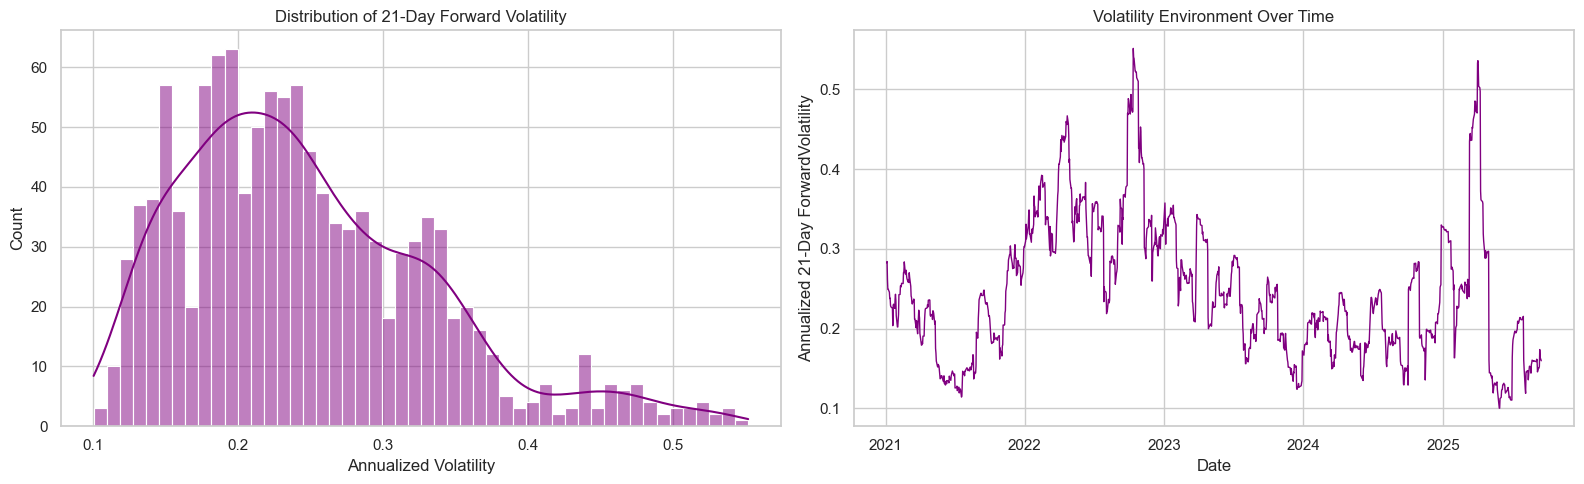


Feature vs. Target Relationships


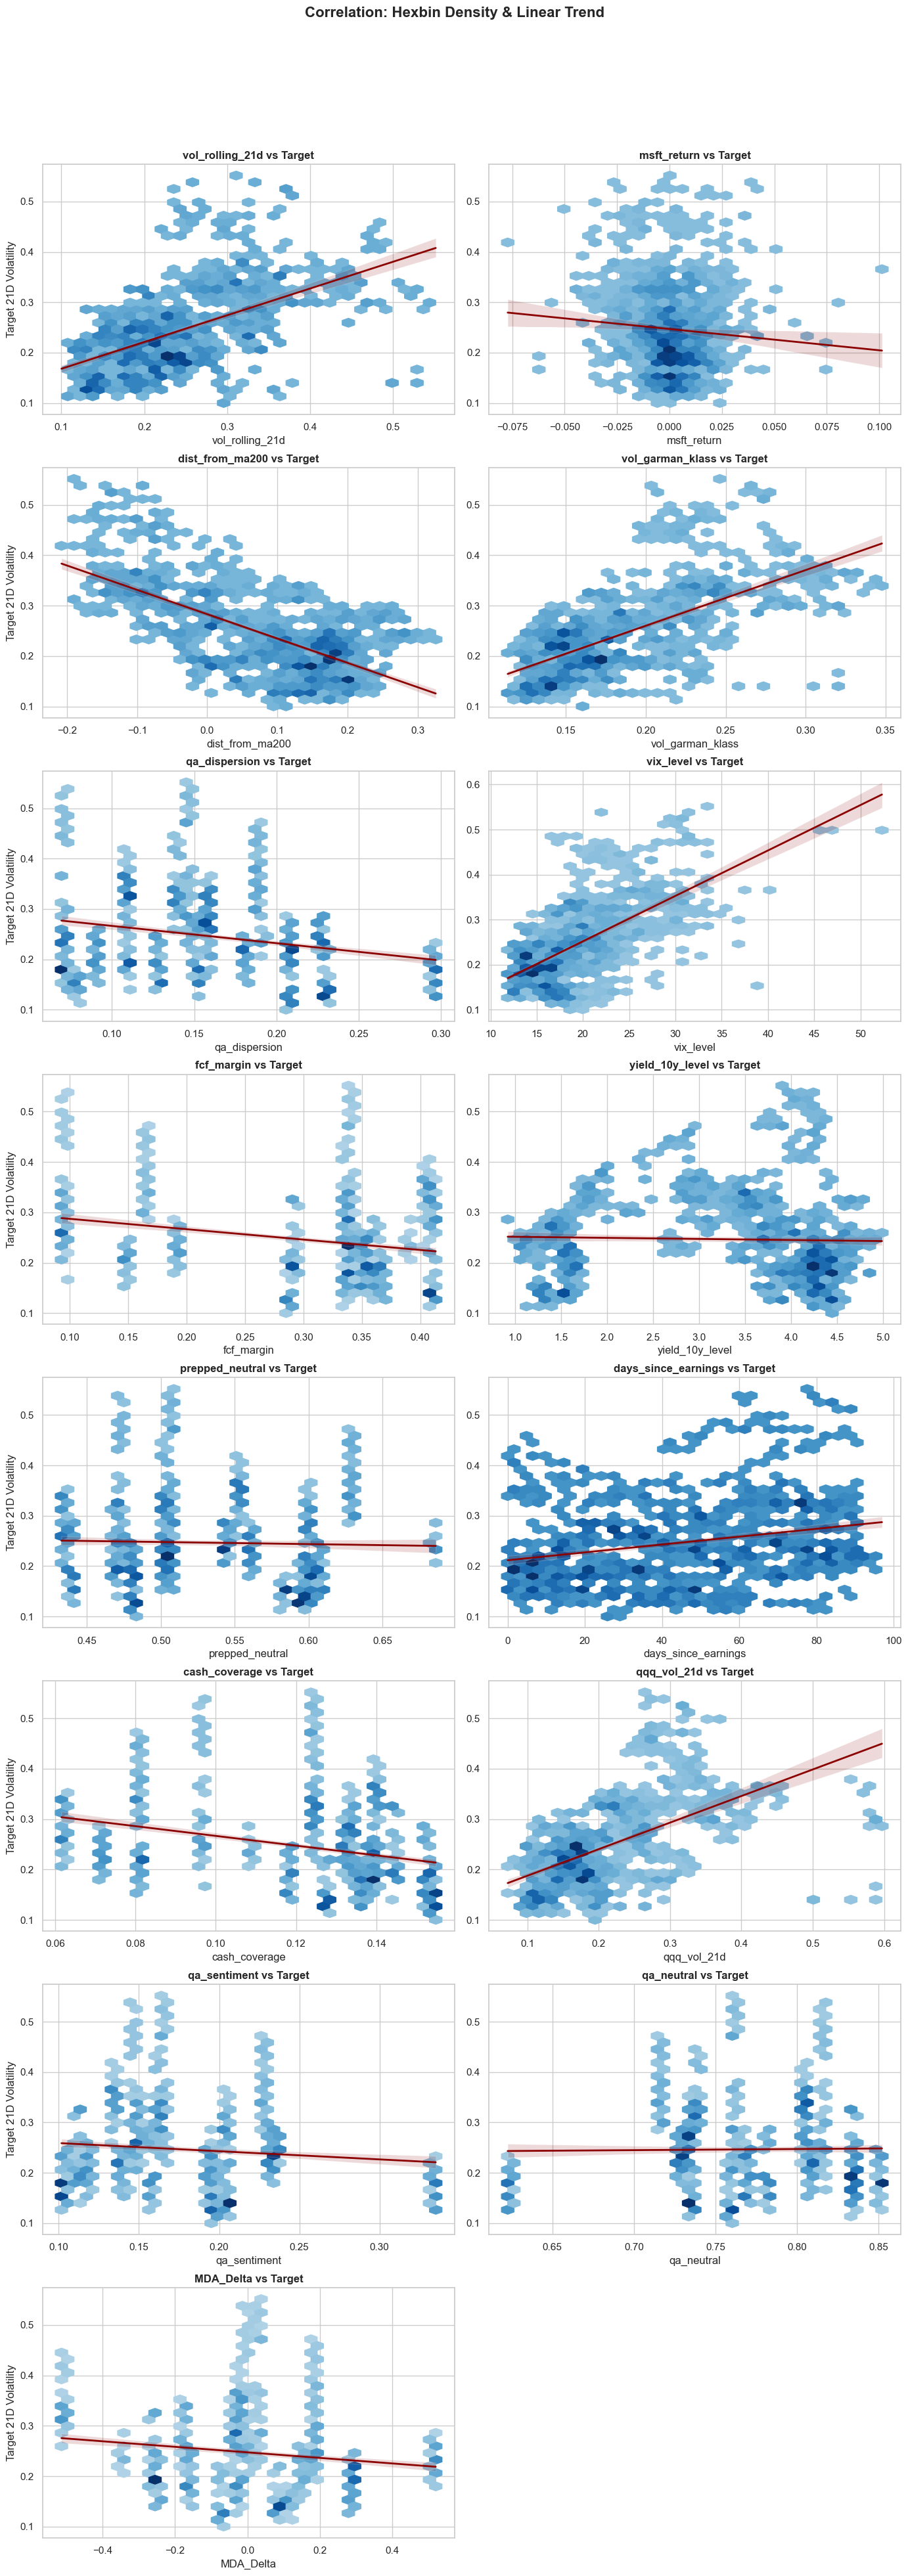


 Feature Correlation Matrix (Spearman)


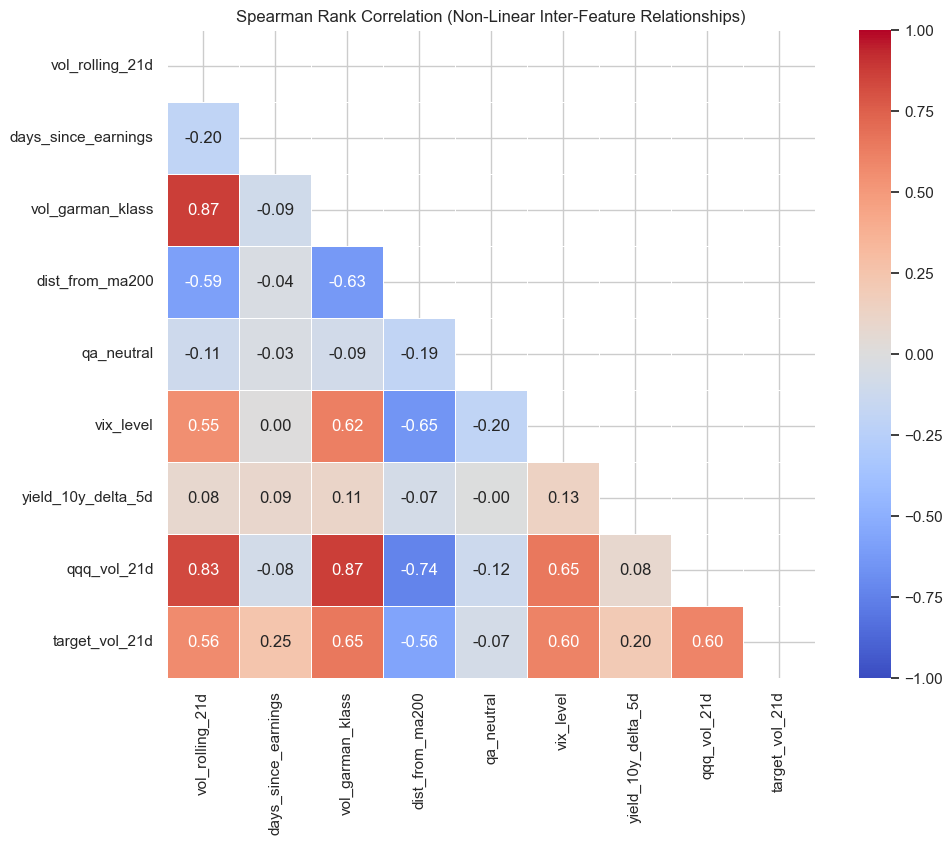

In [ ]:


print("Quantitative EDA on Training Data...")


df['trading_date'] = pd.to_datetime(df['trading_date'])
df = df.sort_values('trading_date')

# Define our core feature groups for targeted analysis
target = 'target_vol_21d'
core_technicals = ['vol_rolling_21d', 'days_since_earnings', 'vol_garman_klass','dist_from_ma200']
macro_liquidity = ['vix_level', 'yield_10y_delta_5d', 'qqq_vol_21d']

sns.set_theme(style="whitegrid", palette="muted")


print("\ Target Variable Distribution")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#Distribution (Looking for skewness and fat tails)
sns.histplot(df[target], bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of 21-Day Forward Volatility')
axes[0].set_xlabel('Annualized Volatility')

#  Time Series (Looking for Market shifts and clustering)
axes[1].plot(df['trading_date'], df[target], color='purple', linewidth=1)
axes[1].set_title('Volatility Environment Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Annualized 21-Day ForwardVolatility')
plt.tight_layout()
plt.show()


#FEATURE-TARGET LINEARITY (SCATTER & HEXBIN)

print("\nFeature vs. Target Relationships")

# Calculate the grid size dynamically based on how many features we have
num_features = [feat for feat in final_features if feat not in nlp_features]
n_features = len(num_features)
cols = 2
rows = math.ceil(n_features / cols)


fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle("Correlation: Hexbin Density & Linear Trend", fontsize=16, fontweight='bold')
axes = axes.flatten() # Flatten so we can easily iterate over them

for i, feature in enumerate(num_features):
    ax = axes[i]
    
    # Plot the Hexbin and the Regression line on the specific grid axis
    ax.hexbin(df[feature], df[target], gridsize=30, cmap='Blues', mincnt=1,vmin=-15)
    sns.regplot(data=df, x=feature, y=target, scatter=False, color='darkred', line_kws={'linewidth': 2}, ax=ax)
    
    ax.set_title(f'{feature} vs Target', fontweight='bold')
    ax.set_xlabel(feature)
    
    if i % cols == 0:
        ax.set_ylabel("Target 21D Volatility")
    else:
        ax.set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.92) 
plt.show()

# MULTICOLLINEARITY & CLUSTERING
print("\n Feature Correlation Matrix (Spearman)")
# We use Spearman (Rank) correlation because financial relationships have non-linear relationships
features_for_corr = core_technicals + macro_liquidity + [target]
corr_matrix = df[features_for_corr].corr(method='spearman')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5)
plt.title("Spearman Rank Correlation (Non-Linear Inter-Feature Relationships)")
plt.show()





In [331]:

def generate_bar_eda(df, final_features,target_col='target_vol_21d', date_col='trading_date'):
    """
    Generates correlation charts focusing strictly on the final pruned features.
    """
    print("Generating Model-Driven EDA for Final Presentation...")
    
    
    
    # Ensure date is sorted
    df_eda = df.copy()
    df_eda[date_col] = pd.to_datetime(df_eda[date_col])
    df_eda = df_eda.sort_values(date_col).set_index(date_col)

    plt.figure(figsize=(12, 8))
    
    # Calculate correlation to target, drop the target itself, and sort
    correlations = df_eda[final_features + [target_col]].corr(method='spearman')[target_col].drop(target_col)
    correlations = correlations.sort_values()
    
    # Color code: Blue for positive correlation (increases vol), Red for negative (decreases vol)
    colors = ['red' if x < 0 else 'blue' for x in correlations]
    
    correlations.plot(kind='barh', color=colors, width=0.7)
    plt.axvline(0, color='black', linewidth=1)
    plt.title('Linear Alpha Profile: Feature Correlation to 21-Day Volatility', pad=20, fontsize=14, fontweight='bold')
    plt.xlabel('Spearman Correlation Coefficient')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()



Generating Model-Driven EDA for Final Presentation...


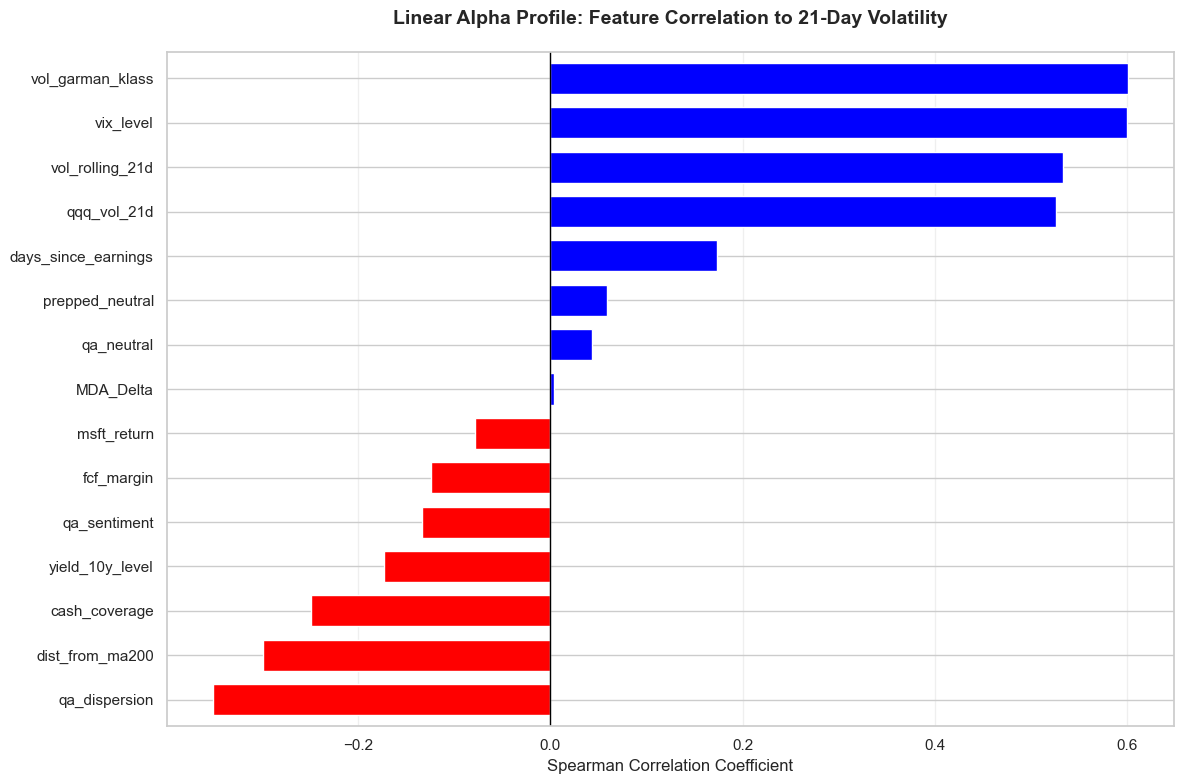

In [290]:
generate_bar_eda(df,final_features)


Analyzing Step-Function Features (NLP & Fundamentals)...


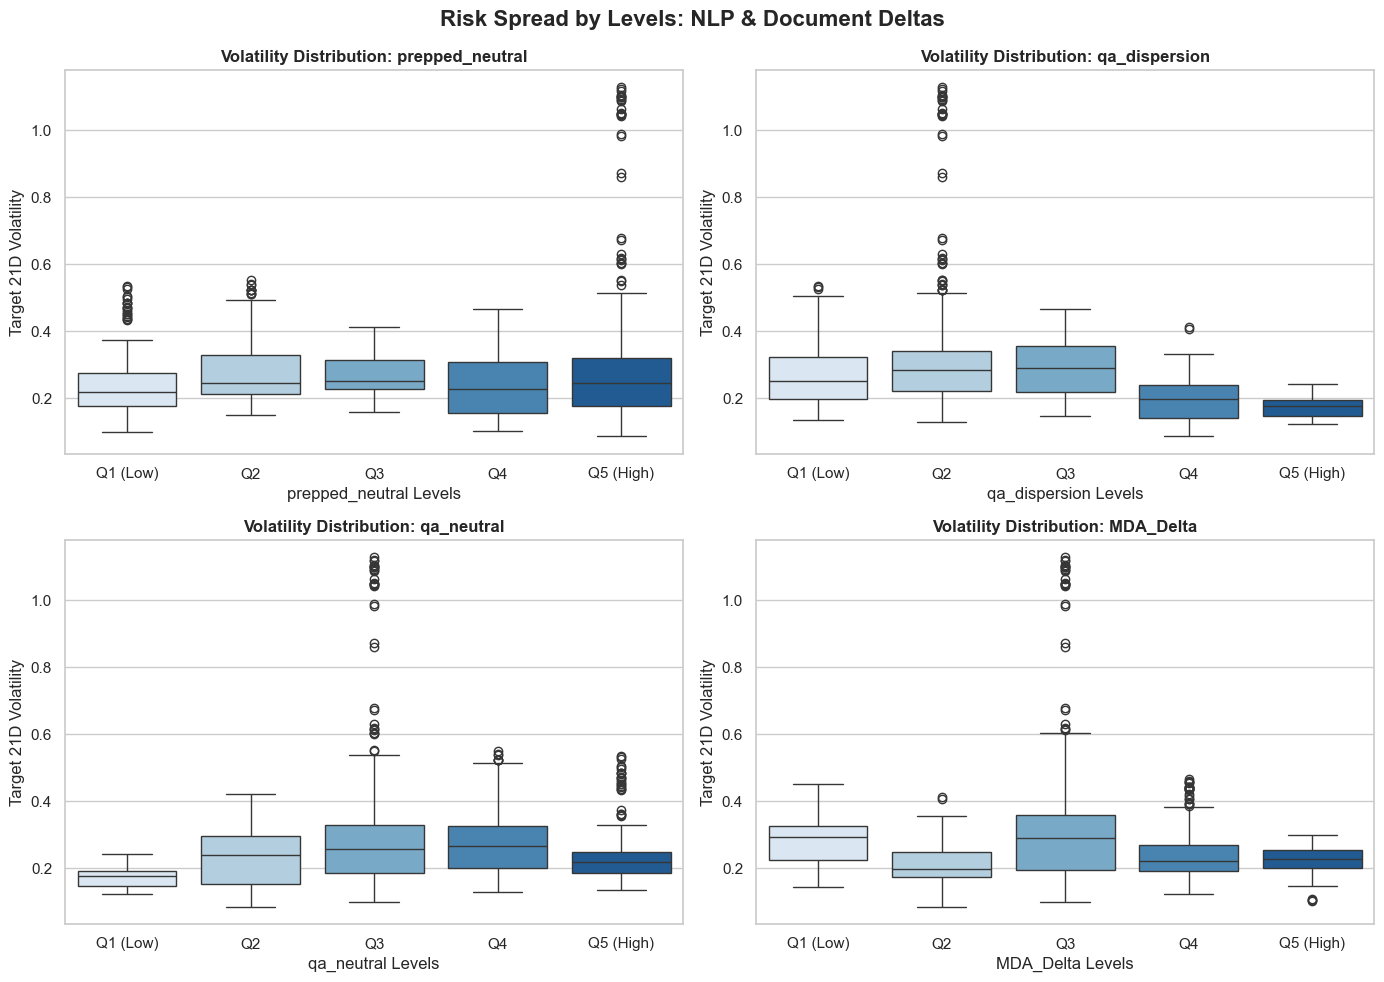


Analyzing future volatality with time passing post interval


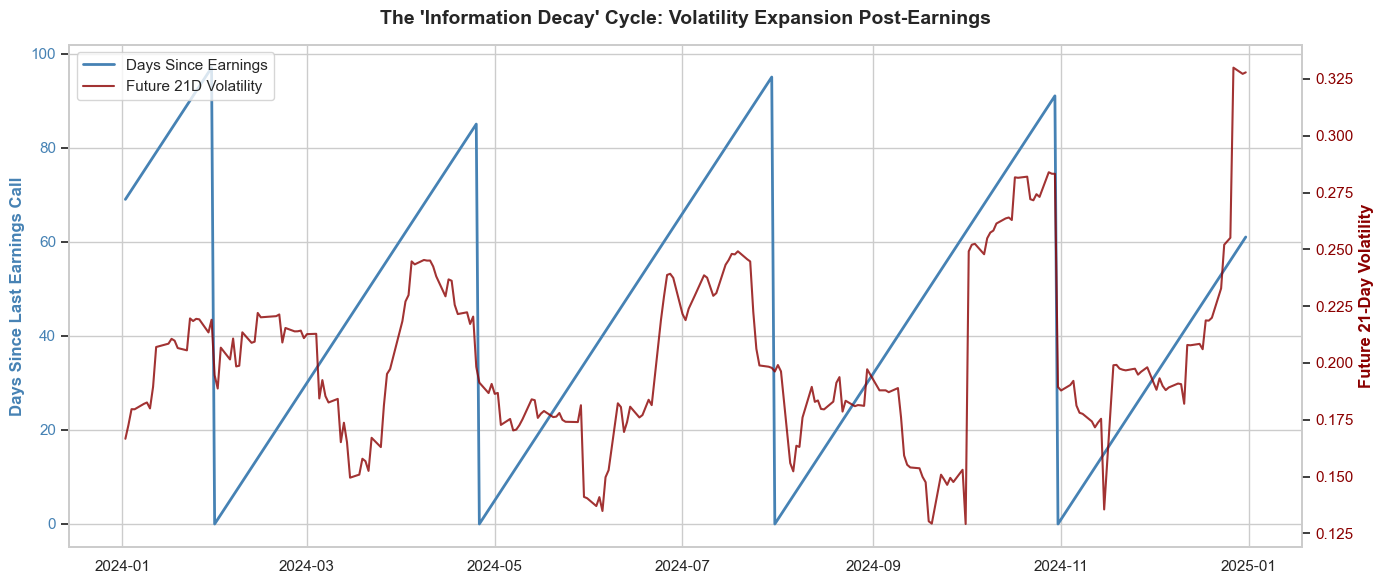

In [ ]:

sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white' 
plt.rcParams['axes.facecolor'] = 'white'


#  STEP-FUNCTION FEATURES (NLP & Fundamentals)
print("\nAnalyzing Step-Function Features (NLP & Fundamentals)...")

top_step = ['prepped_neutral', 'qa_dispersion', 'qa_neutral', 'MDA_Delta']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Risk Spread by Levels: NLP & Document Deltas", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feature in enumerate(top_step):
    ax = axes[i]
    
    # Create 5 buckets using pd.cut 
    df['temp_level'] = pd.cut(df[feature], bins=5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])
    
    
    sns.boxplot(data=df, x='temp_level', y=target, palette='Blues', ax=ax)
    
    ax.set_title(f"Volatility Distribution: {feature}", fontweight='bold')
    ax.set_xlabel(f"{feature} Levels")
    ax.set_ylabel("Target 21D Volatility")

df.drop(columns=['temp_level'], inplace=True)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

#  THE TEMPORAL features
print("\nAnalyzing future volatality with time passing post interval")


# Take a 1-year slice (roughly 252 trading days)
slice_df = df[df.trading_date.dt.year==2024].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))


ax1.plot(slice_df['trading_date'], slice_df['days_since_earnings'], color='steelblue', linewidth=2, label='Days Since Earnings')
ax1.set_ylabel('Days Since Last Earnings Call', color='steelblue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Plot Future Volatility on secondary axis (Top)
ax2 = ax1.twinx()
ax2.plot(slice_df['trading_date'], slice_df[target], color='darkred', linewidth=1.5, alpha=0.8, label='Future 21D Volatility')
ax2.set_ylabel('Future 21-Day Volatility', color='darkred', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkred')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, facecolor='white')

plt.title("The 'Information Decay' Cycle: Volatility Expansion Post-Earnings", pad=15, fontsize=14, fontweight='bold')
plt.grid(False) 
plt.tight_layout()
plt.show()

--- Quarter Environment: EXTREME EVENT DATES ---
Threshold for 'Tail Risk' set at Volatility > 0.5094

Year-Month  Days in Fat Tail
   2022-10                10
   2020-03                19
   2020-02                16


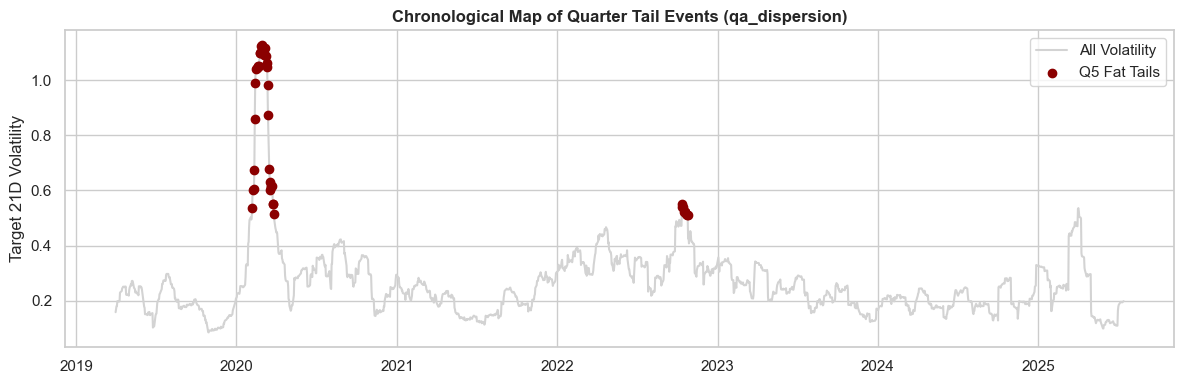

In [332]:


def investigate_tails(df, feature='qa_dispersion', target='target_vol_21d', tail_percentile=0.90):
    """
    Isolates the most chaotic regime (Q5) and extracts the exact dates 
    where the fat-tail volatility blowups actually occurred.
    """
    
    # Recreate the interval 
    df_temp = df.copy()
    df_temp['temp_level'] = pd.cut(df_temp[feature], bins=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    
    # Isolate ONLY the highest risk regime
    q_data = df_temp[df_temp['temp_level'] == 'Q2']
    
    #  Define the "Tail Risk" (e.g., the top 10% worst days within defined quarter)
    tail_threshold = q_data[target].quantile(tail_percentile)
    
    # Filter for the exact days that broke the threshold
    fat_tail_events = q_data[q_data[target] >= tail_threshold].copy()
    
    # Extract just the Year and Month for a clean report
    fat_tail_events['Year-Month'] = pd.to_datetime(fat_tail_events['trading_date']).dt.to_period('M')
    
    print(f"--- Quarter Environment: EXTREME EVENT DATES ---")
    print(f"Threshold for 'Tail Risk' set at Volatility > {tail_threshold:.4f}\n")
    
    # Group by month to see when the clusters happened
    event_clusters = fat_tail_events.groupby('Year-Month').size().reset_index(name='Days in Fat Tail')
    print(event_clusters.sort_values('Year-Month', ascending=False).to_string(index=False))
    
    # Plot them on a timeline to visualize the clusters
    plt.figure(figsize=(12, 4))
    plt.plot(pd.to_datetime(df_temp['trading_date']), df_temp[target], color='lightgrey', label='All Volatility')
    plt.scatter(pd.to_datetime(fat_tail_events['trading_date']), fat_tail_events[target], color='darkred', label='Q5 Fat Tails', zorder=5)
    plt.title(f"Chronological Map of Quarter Tail Events ({feature})", fontweight='bold')
    plt.ylabel("Target 21D Volatility")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Run it on your dataframe
investigate_tails(df, feature='qa_dispersion')

Generating Macro vs Micro Regime Matrix...


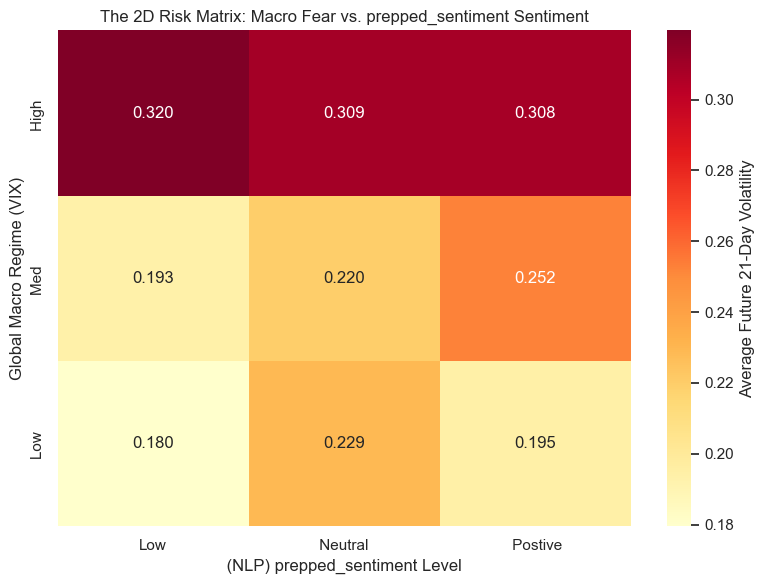

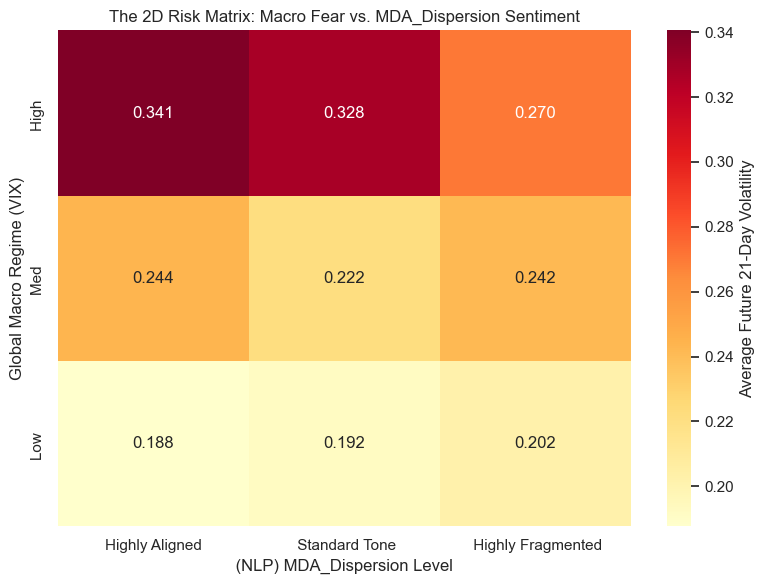

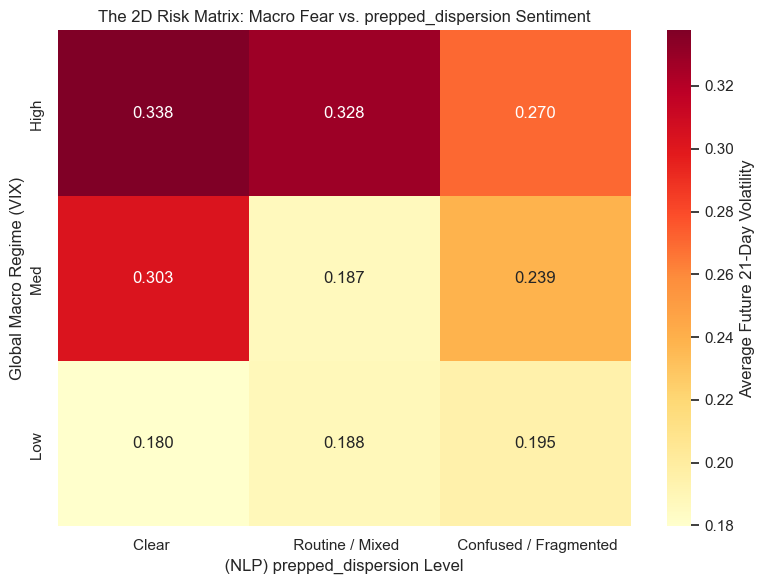

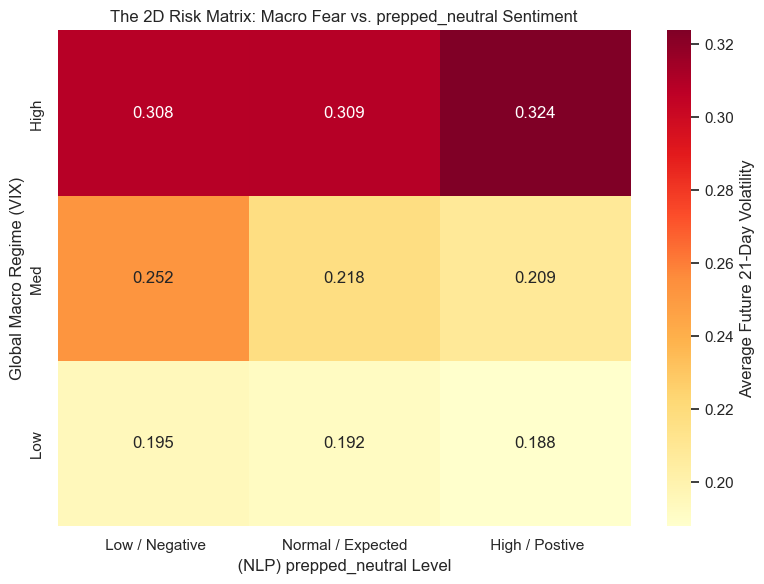

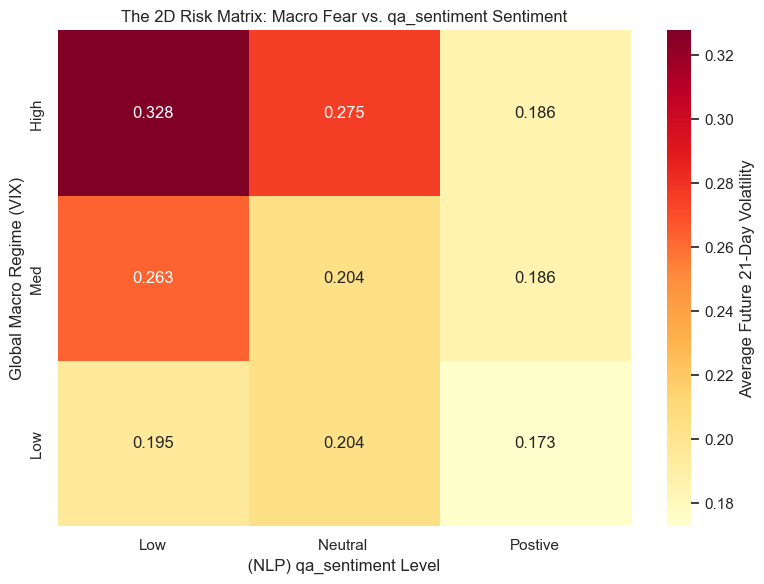

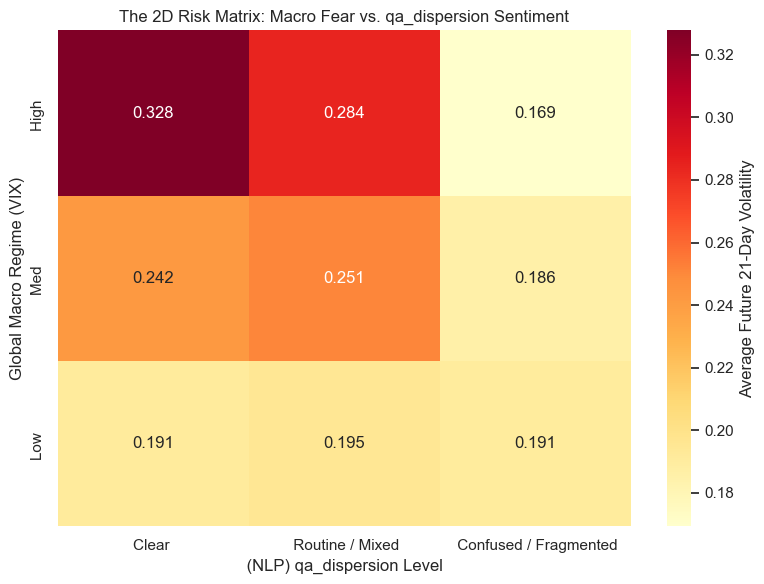

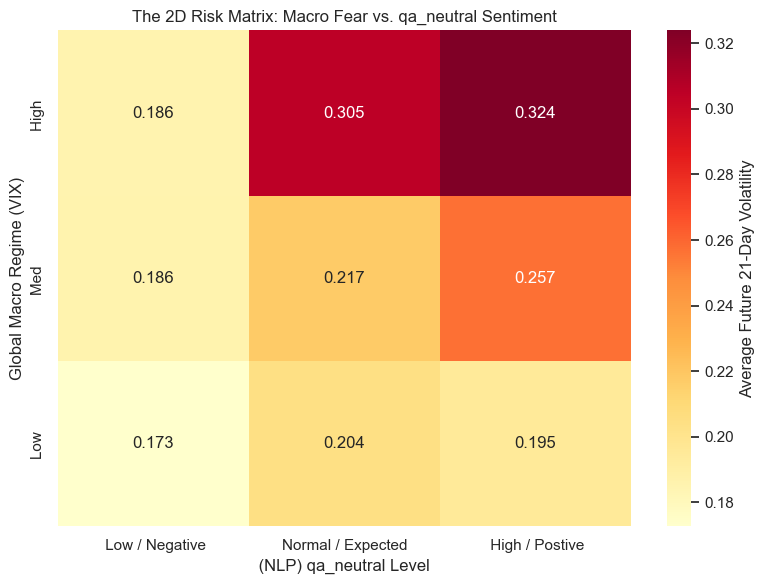

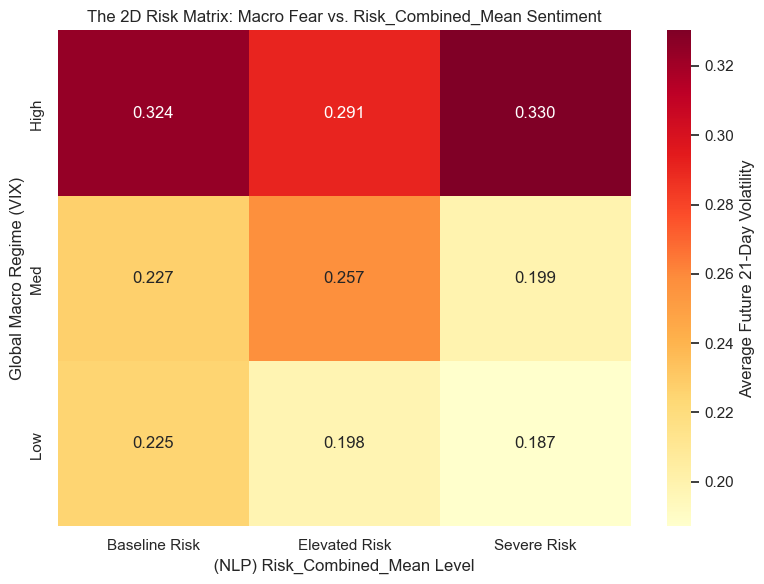

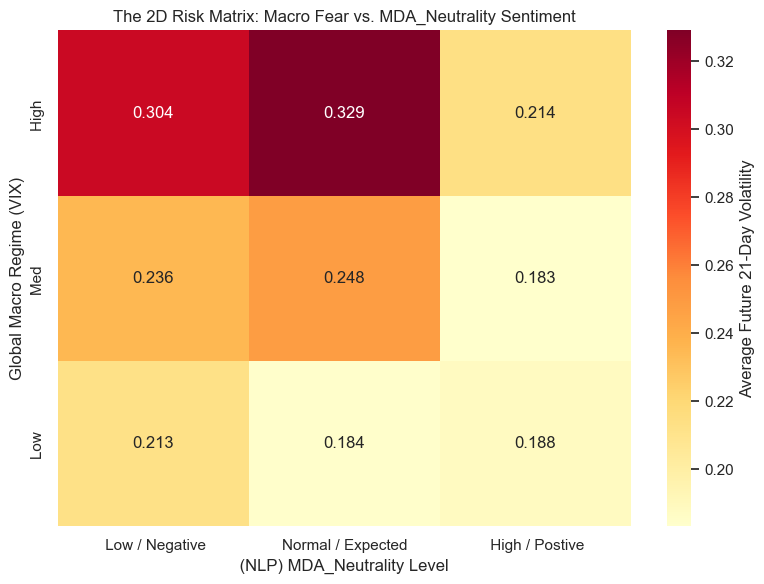

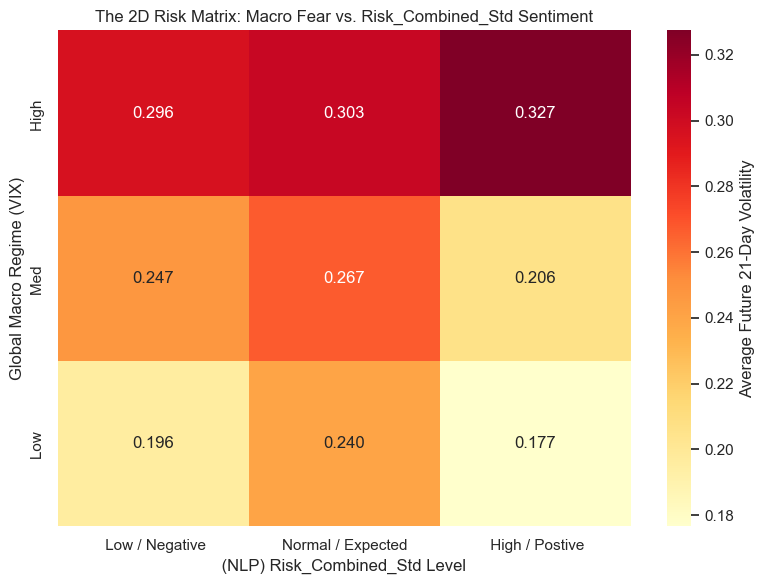

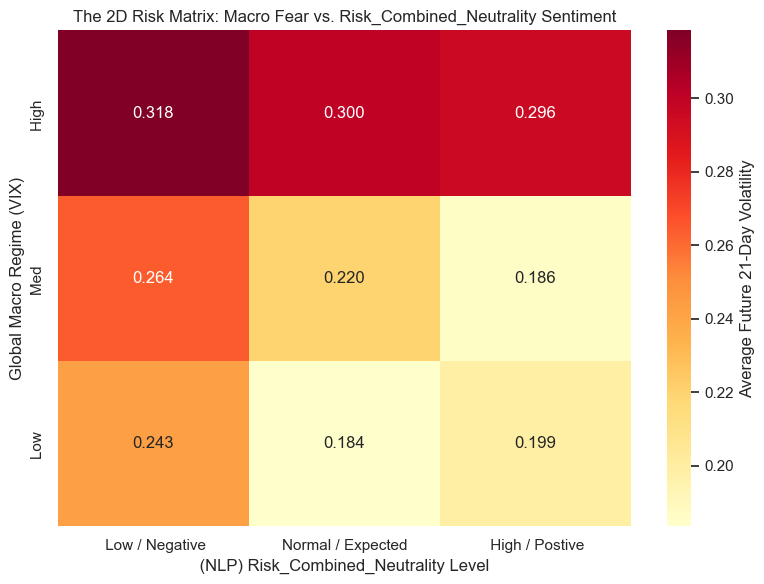

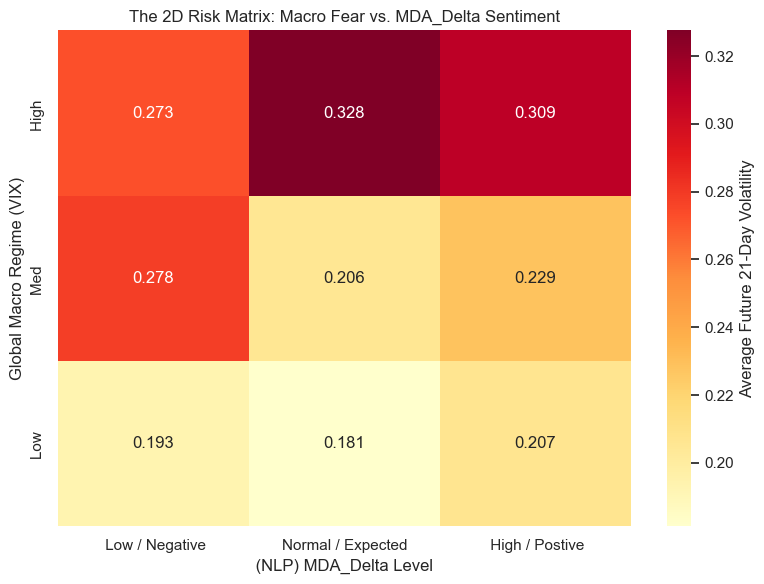

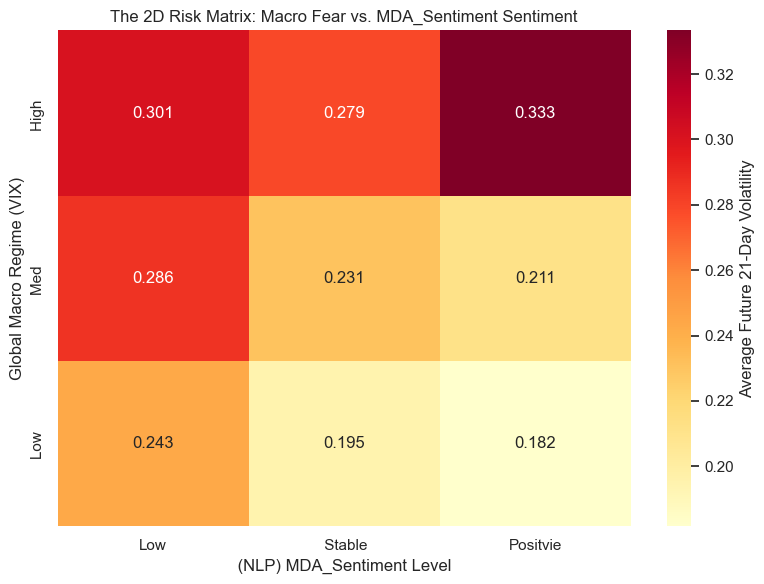

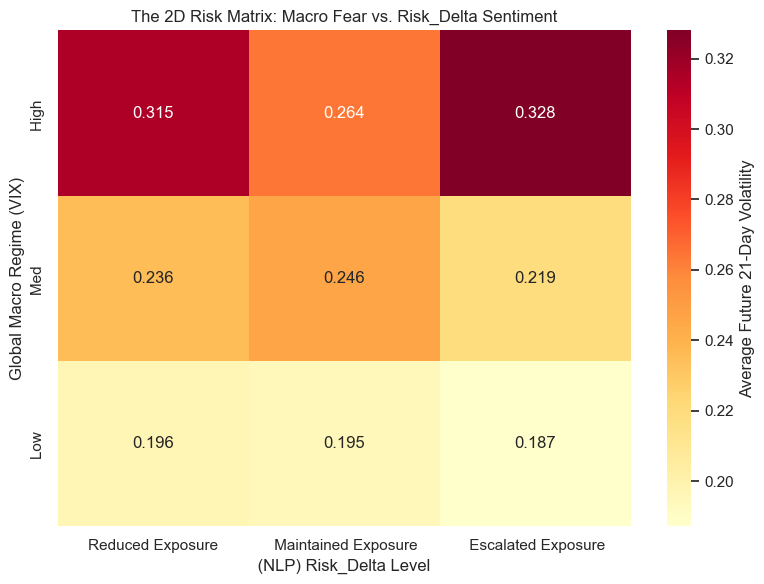

In [ ]:
df_recent =df[df.trading_date >= '2021-01-01']


nlp_label_map = {
    
    'qa_dispersion': ['Clear ', ' Routine / Mixed', ' Confused / Fragmented'],
    'prepped_dispersion': ['Clear ', ' Routine / Mixed', ' Confused / Fragmented'],
    'MDA_Dispersion': ['Highly Aligned', ' Standard Tone', ' Highly Fragmented'],
    
    'qa_sentiment': ['Low', 'Neutral ', 'Postive'],
    'prepped_sentiment': ['Low', ' Neutral ', ' Postive'],
    
    'MDA_Sentiment': ['Low', ' Stable', 'Positvie'],
    
    'Risk_Combined_Mean': ['Baseline Risk', 'Elevated Risk', 'Severe Risk'],
    'Risk_Delta': ['Reduced Exposure', ' Maintained Exposure', ' Escalated Exposure']
}

# A generic fallback just in case a new feature slips into the loop
default_labels = [' Low / Negative', 'Normal / Expected', ' High / Postive']


print("Generating Macro vs Micro Regime Matrix...")

for f in nlp_features:
    labels = nlp_label_map.get(f, default_labels)
    
    # 1. Create 33rd and 66th percentile bins (Low, Medium, High)
    df_recent['macro_vix_regime'] = pd.qcut(df_recent['vix_level'], q=3, labels=['Low ', 'Med ', 'High '])
    df_recent[f'micro_{f}_regime'] = pd.cut(df_recent[f], bins=3, labels=labels)

    # 2. Build the Pivot Table (Calculate average target volatility for each intersection)
    regime_matrix = pd.pivot_table(
        df_recent, 
        values='target_vol_21d', 
        index='macro_vix_regime', 
        columns=f'micro_{f}_regime', 
        aggfunc=np.median
    )

    # 3. Plot the Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(regime_matrix, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={'label': 'Median Future 21-Day Volatility'})
    plt.title(f"The 2D Risk Matrix: Macro Fear vs. {f} Sentiment")
    plt.xlabel(f" (NLP) {f} Level ")
    plt.ylabel("Global Macro Regime (VIX)")
    plt.gca().invert_yaxis() # Put High VIX at the top for intuitive reading
    plt.tight_layout()
    plt.show()

    # Cleanup
    df_recent.drop(columns=['macro_vix_regime', f'micro_{f}_regime'], inplace=True)

Generating the Information Decay Curve...


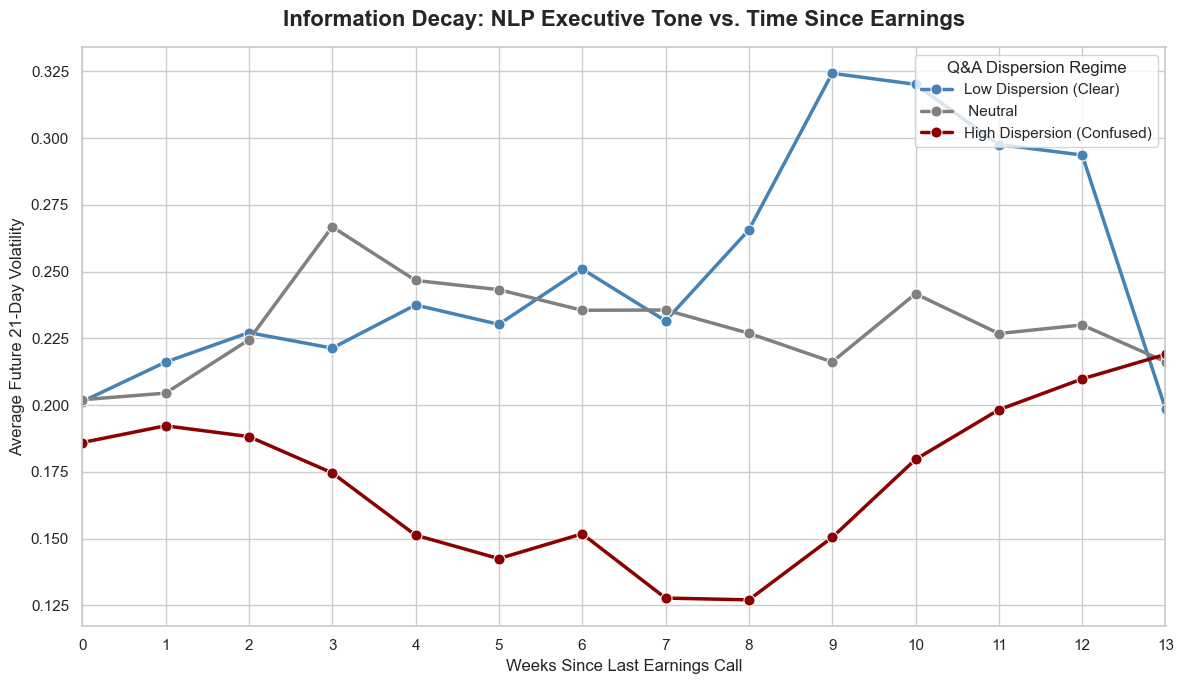

In [ ]:

print("Generating the Information Decay Curve...")

# 1. Create the NLP Regimes (using absolute cuts for step-functions)
# We use 3 bins here  instead of 5 to keep the chart clean and readable
df_recent['nlp_regime'] = pd.cut(
    df_recent['qa_sentiment'], 
    bins=3, 
    labels=['Low Dispersion (Clear)', ' Neutral', 'High Dispersion (Confused)']
)

# 2. Convert 'Days' to 'Weeks' to smooth out the daily noise
df_recent['weeks_since_earnings'] = df_recent['days_since_earnings'] // 7

# 3. Plot the Decay Curve
plt.figure(figsize=(12, 7))

# sns.lineplot automatically calculates the mean volatility for each week 
# and draws a shaded 95% confidence interval around the lines.
sns.lineplot(
    data=df_recent, 
    x='weeks_since_earnings', 
    y=target, 
    hue='nlp_regime', 
    palette=['steelblue', 'gray', 'darkred'], 
    linewidth=2.5,
    estimator=np.median, 
    errorbar=None,
    marker='o',
    markersize=8
)

plt.title("Information Decay: NLP Executive Tone vs. Time Since Earnings", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Weeks Since Last Earnings Call")
plt.ylabel("Average Future 21-Day Volatility")


plt.legend(title="Q&A Dispersion Regime", title_fontsize='12', fontsize='11', loc='upper right', frameon=True, facecolor='white')

# Set x-axis ticks to show the 12-week quarter lifecycle clearly
plt.xticks(range(0, 14))
plt.xlim(0, 13)

plt.tight_layout()
plt.show()


df_recent.drop(columns=['nlp_regime', 'weeks_since_earnings'], inplace=True)

In [334]:


print("Calculating Market-Dependent Spearman Correlations...\n")


correlation_results = []
target = 'target_vol_21d'

# 3. Loop through all features
for feature in nlp_features: 
    # Calculate Full Timeline Spearman
    corr_full = df[feature].corr(df[target], method='spearman')
    
    # Calculate Post-2021 Spearman
    corr_post_2021 = df_recent[feature].corr(df_recent[target], method='spearman')
    
    # Calculate the How much the correlation changed by dropping 2020)
    alpha_unlocked = abs(corr_post_2021) - abs(corr_full)
    
    correlation_results.append({
        'Feature': feature,
        'Full Timeline (Inc. 2020)': corr_full,
        'Fundamental Regime (Post-2021)': corr_post_2021,
        'Signal Improvement': alpha_unlocked
    })

#Format and display the clean table
corr_table = pd.DataFrame(correlation_results)
corr_table.to_csv('./corr_change.csv',index=False)
# Sort by the Post-2021 correlation strength (absolute value so negative correlations rank properly)
corr_table = corr_table.reindex(corr_table['Fundamental Regime (Post-2021)'].abs().sort_values(ascending=False).index)


display_table = corr_table.style.format({
    'Full Timeline (Inc. 2020)': "{:.3f}",
    'Fundamental Regime (Post-2021)': "{:.3f}",
    'Signal Improvement': "{:+.3f}"
}).background_gradient(subset=['Fundamental Regime (Post-2021)'], cmap='Blues')

display(display_table)

Calculating Market-Dependent Spearman Correlations...



,Feature,Full Timeline (Inc. 2020),Fundamental Regime (Post-2021),Signal Improvement
7,Risk_Combined_Mean,-0.275,-0.348,+0.073
10,Risk_Combined_Neutrality,-0.279,-0.327,+0.048
5,qa_dispersion,-0.351,-0.281,-0.070
12,MDA_Sentiment,-0.180,-0.250,+0.070
13,Risk_Delta,-0.220,-0.199,-0.021
11,MDA_Delta,0.004,-0.114,+0.110
4,qa_sentiment,-0.133,-0.084,-0.049
8,MDA_Neutrality,-0.161,-0.082,-0.080
2,prepped_dispersion,-0.098,-0.064,-0.034
9,Risk_Combined_Std,-0.063,-0.061,-0.002
